In [1]:
# Imports and Setup
import pandas as pd
import numpy as np
import ast
import matplotlib.pyplot as plt
from matplotlib import cm
from matplotlib.colorbar import ColorbarBase
from matplotlib.colors import Normalize
from mpl_toolkits.axes_grid1 import make_axes_locatable
import seaborn as sns
from scipy.stats import norm
import scipy.stats as stats
from scipy.optimize import curve_fit
from scipy.stats import sem
from scipy.optimize import minimize
from statsmodels.stats.anova import AnovaRM

import warnings
warnings.filterwarnings('ignore')


In [2]:
def weibull_psychometric(x, alpha, beta, gamma, lambd):
    """
    Weibull psychometric function with lapse rate.

    Parameters:
    x : array_like
        Stimulus intensity (can be scalar or array).
    alpha : float
        Threshold (scale parameter).
    beta : float
        Slope (shape parameter).
    gamma : float
        Guess rate (lower asymptote).
    lambd : float
        Lapse rate (1 - upper asymptote).

    Returns:
    y : array_like
        Response probability for each x.
    """
    x = np.asarray(x)
    exponent = -1 * (x / alpha) ** beta
    y = gamma + (1 - gamma - lambd) * (1 - np.exp(exponent))
    return y


In [3]:
# Negative log-likelihood function
def neg_log_likelihood(params, x, n_trials, n_significant):
    alpha, beta, gamma, lambd = params
    p_sig = weibull_psychometric(x, alpha, beta, gamma, lambd)
    # Avoid log(0) by clipping probabilities
    p_sig = np.clip(p_sig, 1e-6, 1 - 1e-6)
    # Binomial log-likelihood
    log_likelihood = n_significant * np.log(p_sig) + (n_trials - n_significant) * np.log(1 - p_sig)
    return -np.sum(log_likelihood)


In [6]:
# TAPPING
df_tap_common = pd.read_csv('/Users/bastugb/Desktop/repetition_coherence_project/df_tap_common.csv') 

In [7]:
len(df_tap_common['participant_id'].unique())

27

In [8]:
# # TAPPING
# df_tap = pd.read_csv('/Users/bastugb/Desktop/repetition_coherence_project/df_tap_common.csv') 
# # Extracting values and creating new columns
# df_tap['participant_id'] = df_tap['filename'].str.extract(r'pid(\d+)').astype(int)
len(df_tap_common['participant_id'].unique())

27

In [9]:
df_tap_common['block_idx'] = df_tap_common['filename'].str.extract(r'block_(\d+)').astype(int)
df_tap_common['trial_idx'] = df_tap_common['filename'].str.extract(r'itrial_(\d+)').astype(int)
df_tap_common['actual_onset_values'] = df_tap_common['actual_onset_values'].apply(lambda x: ast.literal_eval(x))
df_tap_common['tap_onset_values'] = df_tap_common['tap_onset_values'].apply(lambda x: ast.literal_eval(x))
df_tap_common['percentage'] = df_tap_common['percentage'].apply(lambda x: round(x, 3))
df_tap_common['n_tap'] = df_tap_common['tap_onset_values'].apply(len) # Count number of taps

In [10]:
len(df_tap_common)

5610

In [11]:
# Convert tap_onset_values (assumed list/array of sample indices) to seconds
sample_rate = 44100
df_tap_common['tap_onset_s'] = df_tap_common['tap_onset_values'].apply(lambda taps: np.array(taps) / sample_rate)
df_tap_common['actual_onset_s'] = df_tap_common['actual_onset_values'].apply(lambda onsets: np.array(onsets) / sample_rate)

In [12]:
original_len = len(df_tap_common)

# Filter out rows where 'tap_onset_s' has 1 or fewer values
df_tap_common = df_tap_common[
    df_tap_common['tap_onset_s'].apply(lambda x: isinstance(x, (list, np.ndarray)) and len(x) > 2)
]

removed = original_len - len(df_tap_common)
print(f"Removed {removed} rows with 1 or fewer tap_onset_s values.")

Removed 5 rows with 1 or fewer tap_onset_s values.


In [13]:
df_tap_common['is_outlier'] = False

# Group by percentage and unitdur
for (perc, dur), group in df_tap_common.groupby(['percentage', 'unit_dur']):
    Q1 = group['n_tap'].quantile(0.25)
    Q3 = group['n_tap'].quantile(0.75)
    IQR = Q3 - Q1
    lower = Q1 - 1.5 * IQR
    upper = Q3 + 1.5 * IQR
    # lower = group['n_tap_filtered'].quantile(0.05)
    # upper = group['n_tap_filtered'].quantile(0.95)
    # Mask for outliers
    outlier_mask = (group['n_tap'] < lower) | (group['n_tap'] > upper)
    # outlier_mask = (group['n_tap'] > upper)
    # Mark them in the original DataFrame
    df_tap_common.loc[group.index, 'is_outlier'] = outlier_mask

# Filter out the outliers
df_tap_clean = df_tap_common[~df_tap_common['is_outlier']].reset_index(drop=True)

num_outliers = len(df_tap_common) - len(df_tap_clean)
percentage_outliers = 100 * num_outliers / len(df_tap_common)
print(f"{num_outliers} outliers removed ({percentage_outliers:.2f}% of total)")

446 outliers removed (7.96% of total)


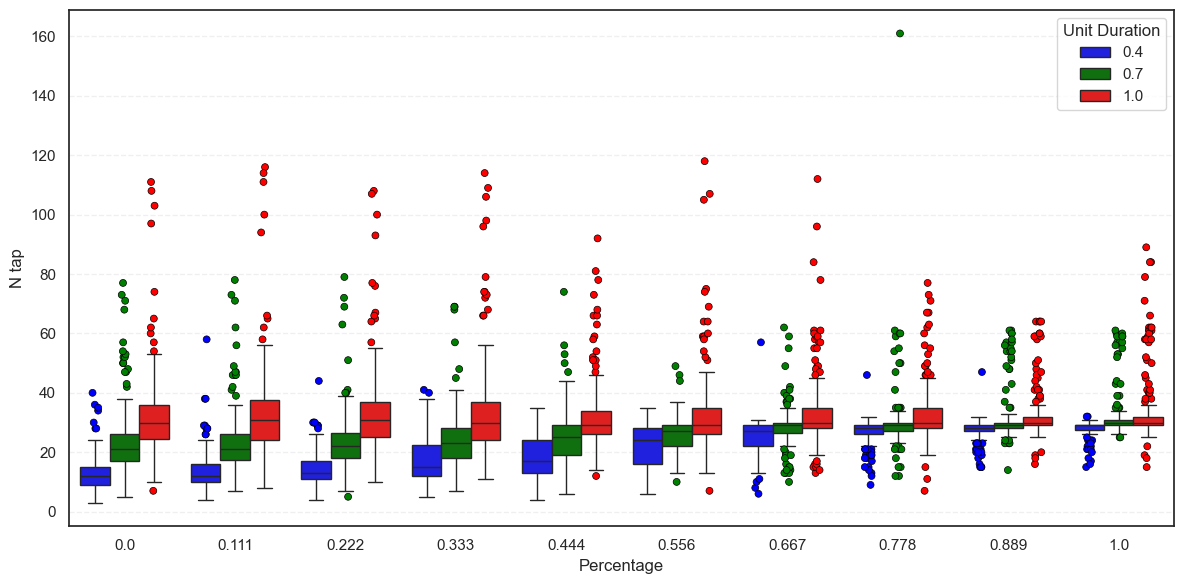

In [14]:
sns.set(style="white")

plt.figure(figsize=(12, 6))

# Define custom color palette
custom_palette = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}

# Base boxplot without outliers
sns.boxplot(
    data=df_tap_common,
    x='percentage',
    y='n_tap',
    hue='unit_dur',
    palette=custom_palette,
    showfliers=False
)

# Overlay outliers using same color mapping
outliers = df_tap_common[df_tap_common['is_outlier']]
sns.stripplot(
    data=outliers,
    x='percentage',
    y='n_tap',
    hue='unit_dur',
    marker='o',
    dodge=True,
    palette=custom_palette,
    edgecolor='black',
    linewidth=0.5,
    size=5
)

# Clean up duplicate legends
handles, labels = plt.gca().get_legend_handles_labels()
n_durs = df_tap_common['unit_dur'].nunique()
plt.legend(handles[:n_durs], labels[:n_durs], title='Unit Duration')
# plt.axhline(y=30, color='gray', linestyle='--', linewidth=1.2)
# plt.title('Median ITI)')
plt.ylabel('N tap')
plt.xlabel('Percentage')
plt.grid(True, axis='y', linestyle='--', alpha=0.3)
plt.tight_layout()
plt.show()

In [15]:
from tapping_analysis_repo import compute_sliding_window_values
df_tap_clean[['slide_resultant_length', 'slide_rayleigh_z', 'z_scored_r']] = df_tap_clean.apply(
    lambda row: pd.Series(compute_sliding_window_values(row['actual_onset_s'], row['tap_onset_s'], row['unit_dur'])),
    axis=1
)

In [16]:
# Organize .... lists by (participant, unitdur, percentage)
aligned_data = {}  # Dictionary to store progressions

for (participant_id, unitdur, percentage), group in df_tap_clean.groupby(['participant_id', 'unit_dur', 'percentage']):
    zvals = []
    
    for z_list in group['z_scored_r']:
        zvals.append(z_list)  # Store lists

    aligned_data[(participant_id, unitdur, percentage)] = zvals  # Store per participant

# Find the max sequence length (to pad shorter ones)
max_length = max(max(len(trial) for trial in trials) for trials in aligned_data.values())

# Convert to DataFrame, padding shorter trials with NaN
df_avg_zvals = {key: np.nanmean([np.pad(trial, (0, max_length - len(trial)), constant_values=np.nan) 
                               for trial in trials], axis=0) 
              for key, trials in aligned_data.items()}

# that's grouped by participant id, percentage, and unit dur.
df_avg_zvals = pd.DataFrame(df_avg_zvals)  # Convert to DataFrame


In [17]:
# this is grouped by unit dur and percentage only. 
# averages of averages
df_avg_zvals.columns = pd.MultiIndex.from_tuples(df_avg_zvals.columns, names=['participant', 'unit_dur', 'percentage'])
grouped = df_avg_zvals.groupby(level=['unit_dur', 'percentage'], axis=1)
df_mean_zvals = grouped.aggregate(np.nanmean)

In [18]:
# Define the exponential saturation model
def exp_saturation(x, a, b, c):
    return a * (1 - np.exp(-b * x)) + c

In [19]:
# Store all fits per participant for later averaging
all_fits = []

x_data = np.arange(max_length)

for key, trials in aligned_data.items():
    participant_id, unitdur, percentage = key

    # Average across trials for this participant
    avg_z = np.nanmean([np.pad(trial, (0, max_length - len(trial)), constant_values=np.nan)
                        for trial in trials], axis=0)

    mask = ~np.isnan(avg_z)
    if np.sum(mask) > 5:  # Require some data points
        try:
            popt, _ = curve_fit(exp_saturation, x_data[mask], avg_z[mask], p0=[1, 0.1, 0], maxfev=10000)
            all_fits.append({
                'participant_id': participant_id,
                'unit_dur': unitdur,
                'percentage': percentage,
                'a': popt[0],
                'b': popt[1],
                'c': popt[2]
            })
        except RuntimeError:
            pass


In [20]:
df_fits = pd.DataFrame(all_fits)

In [21]:
summary_df_fits = df_fits.groupby(['unit_dur', 'percentage']).agg(
    mean_b=('b', 'mean'),
    std_b=('b', 'std')
).reset_index()

In [22]:
def get_time_to_threshold(x, y, threshold_ratio=0.9):
    y_max = np.nanmax(y)
    threshold = y_max * threshold_ratio
    above = np.where(y >= threshold)[0]
    return x[above[0]] if len(above) > 0 else np.nan


In [23]:
p_threshold = 0.05
z_threshold = norm.ppf(1 - p_threshold)  # One-sided test

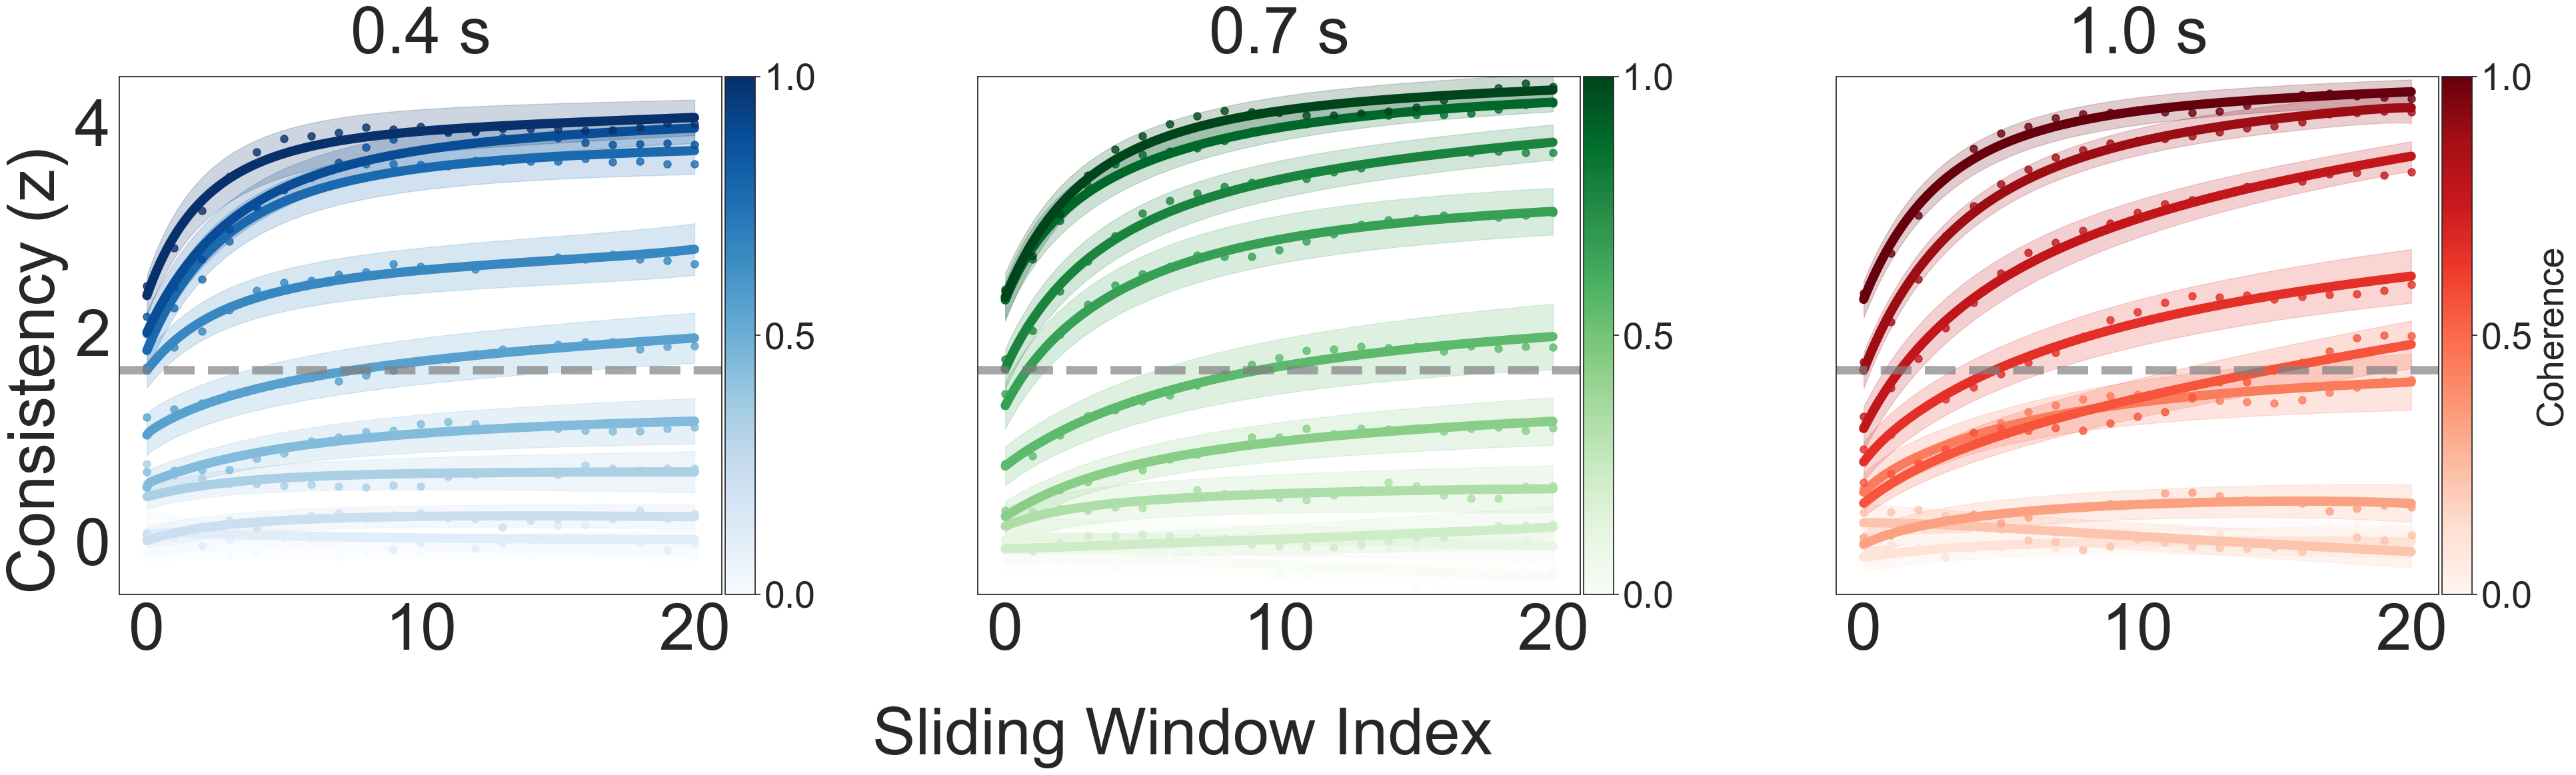

In [73]:
sns.set(style="white")
# 20 sliding windows in total, for all conditions
sliding_window_indices = np.arange(21)  

# Define x values for smooth curves
x_fit = np.linspace(0, max_length - 1, 500)

# Plot average fit for each condition
fig, axs = plt.subplots(1, 3, figsize=(42, 12), sharey=True)
durations = sorted(df_fits['unit_dur'].unique())
colormaps = {0.4: cm.Blues, 0.7: cm.Greens, 1.0: cm.Reds}


for i, dur in enumerate(durations):
    
    ax = axs[i]
    cmap = colormaps[dur]

    # Normalize percentage values to [0, 1] for gradient mapping
    percentages = sorted(df_fits['percentage'].unique())
    normalizee = Normalize(vmin=min(percentages), vmax=max(percentages))

    for perc in percentages:

        # Access data from multi-index DataFrame
        actual_series = df_mean_zvals[(dur, perc)].values  # shape = (21,)
        subset = df_fits[(df_fits['unit_dur'] == dur) & (df_fits['percentage'] == perc)]

        
        if not subset.empty:
            y_fits = []
            for _, row in subset.iterrows():
                y_fits.append(exp_saturation(x_fit, row['a'], row['b'], row['c']))
            
            y_fits = np.array(y_fits)
            mean_fit = np.nanmean(y_fits, axis=0)
            sem_fit = sem(y_fits, axis=0)

            # Assign color based on percentage gradient
            color = cmap(normalizee(perc))

            ax.plot(x_fit, mean_fit, color=color, label=f'{perc:.2f}', lw=10)
            ax.fill_between(x_fit, mean_fit - sem_fit, mean_fit + sem_fit, color=color, alpha=0.2)

            ax.plot(sliding_window_indices, actual_series, 'o', color=color, markersize=8, alpha=0.8)

    ax.set_title(f'{dur} s', fontsize=70, pad = 25)
    # ax.set_xlabel('Sliding Window Index', fontsize=18)
    # if i == 0:
    #     ax.set_ylabel('Rayleigh-z', fontsize=18)

    ax.tick_params(labelsize=70)
    ax.set_ylim(bottom=-0.5)
    ax.axhline(z_threshold, color='gray', linestyle='--', linewidth=9, alpha=0.7)
    # ax.text(x_fit[-1], z_threshold + 0.1, f'p < {p_threshold}', color='gray', fontsize=12, ha='right')


    # LEGEND AESTHETICS
    divider = make_axes_locatable(ax)
    cax = divider.append_axes("right", size="5%", pad=0.05)
    # cb = ColorbarBase(cax, cmap=cmap, norm=normalizee)
    cb = ColorbarBase(cax, cmap=cmap, norm=normalizee, ticks=[0, 0.5, 1])

    
    # Show label only for the rightmost subplot
    if i == len(durations) - 1:
        cb.set_label('Coherence', fontsize=40)
    cb.ax.tick_params(labelsize=40)



# --- Shared Axis Labels ---
fig.text(0.5, 0.05, 'Sliding Window Index', ha='center', fontsize=70)
fig.text(0.08, 0.53, 'Consistency (z)', va='center', rotation='vertical', fontsize=70)

         
plt.tight_layout(rect=[0.1, 0.15, 1, 1])  # Adjust layout to leave space for labels
plt.subplots_adjust(wspace=0.35)  # or try 0.5, 0.6 for more space
plt.show()


In [26]:
# Define x values for smooth curves
x_fit = np.linspace(0, max_length - 1, 500)
durations = sorted(df_fits['unit_dur'].unique())
rows = []
for i, dur in enumerate(durations):
    
    # Normalize percentage values to [0, 1] for gradient mapping
    percentages = sorted(df_fits['percentage'].unique())

    for perc in percentages:

        subset = df_fits[(df_fits['unit_dur'] == dur) & (df_fits['percentage'] == perc)]

        if not subset.empty:
            y_fits = []
            for _, row in subset.iterrows():
                y_fit = exp_saturation(x_fit, row['a'], row['b'], row['c'])
                y_fits.append(y_fit)


            
            y_fits = np.array(y_fits)
            mean_fit = np.nanmean(y_fits, axis=0)
            sem_fit = sem(y_fits, axis=0)

        time_50 = get_time_to_threshold(x_fit, mean_fit, 0.5)
        time_90 = get_time_to_threshold(x_fit, mean_fit, 0.9)
        magnitude = np.max(mean_fit)
        rows.append((dur, perc, time_50, time_90, magnitude))


df_speed_magnitude = pd.DataFrame(rows, columns=['unit_dur', 'percentage', 't50', 't90', 'magnitude'])


In [27]:
# Initialize an empty list for individual measures
individual_values = []

# Define x values for fitting
x_fit = np.linspace(0, max_length - 1, 500)

# Loop through each participant fit
for _, row in df_fits.iterrows():
    participant_id = row['participant_id']
    unit_dur = row['unit_dur']
    percentage = row['percentage']

    # Generate the fit curve
    y_fit = exp_saturation(x_fit, row['a'], row['b'], row['c'])

    # Compute metrics
    t50 = get_time_to_threshold(x_fit, y_fit, 0.5)
    t90 = get_time_to_threshold(x_fit, y_fit, 0.9)
    magnitude = np.max(y_fit)

    # Store
    individual_values.append({
        'participant_id': participant_id,
        'unit_dur': unit_dur,
        'percentage': percentage,
        't50': t50,
        't90': t90,
        'magnitude': magnitude
    })

# Convert to DataFrame
df_individual_magnitude = pd.DataFrame(individual_values)


In [28]:
df_filtered = df_individual_magnitude[df_individual_magnitude['percentage'] >= 0.5]

In [29]:
df_filtered['t90'] = df_filtered['t90'] + 1

In [30]:
# Prepare the result list for storing delays
tap_onset_delays_list = []
itis_list = []
# Iterate over each row in the DataFrame
for index, row in df_tap_clean.iterrows():
    # Select the last 20 presentation cycles (actual_onset_s)
    actual_window = row['actual_onset_s'][-20:]
    
    # Select tap onsets (tap_onset_s) that fall within the range of the last 20 presentation cycles
    # Define the range as the first and last actual onset in the window
    start_range = actual_window[0]
    # till the end of the trial which includes: time point of presentation, the duration of the presentation, zero pad
    zero_pad = 0.2
    # end_range = actual_window[-1] + row['unit_dur'] + zero_pad
    end_range = actual_window[-1]
    
    # Select tap onsets that are within this range
    tap_window = np.array(row['tap_onset_s'])
    valid_tap_onsets = tap_window[(tap_window >= start_range) & (tap_window <= end_range)]
    iti = np.diff(np.array(valid_tap_onsets))
    itis_list.append(iti)

    # Find the closest indices in actual_window that are less than or equal to the tap onsets using np.searchsorted
    closest_indices = np.searchsorted(actual_window, valid_tap_onsets, side='right') - 1
    
    # Ensure indices are valid (i.e., actual onset is before tap onset)
    valid_indices = (closest_indices >= 0)
    closest_actuals = np.array(actual_window)[closest_indices[valid_indices]]
    valid_tap_onsets = valid_tap_onsets[valid_indices]
    
    # Compute tap onset delays (difference between tap and actual)
    tap_onset_delays = valid_tap_onsets - closest_actuals
    
    # Add the computed delays for this row to the list
    tap_onset_delays_list.append(tap_onset_delays)

# After processing all rows, you can store the delays in the DataFrame or another structure
df_tap_clean['tap_onset_delays_stabil'] = tap_onset_delays_list
df_tap_clean['itis_stabil'] = itis_list


In [31]:
from tapping_analysis_repo import get_tapping_vectors
df_tap_clean[['tapping_phases_stabil', 'tapping_vectors_stabil']] = df_tap_clean.apply(
    lambda row: pd.Series(get_tapping_vectors(row['tap_onset_delays_stabil'], row['unit_dur'])), 
    axis=1
)

In [32]:
from pycircstat2.descriptive import circ_r,circ_dispersion
from pycircstat2.hypothesis import rayleigh_test

In [33]:
# DESCRIPTIVES (LAST 20 CYCLES)
df_tap_clean['resultant_length'] = df_tap_clean['tapping_phases_stabil'].apply(lambda x: circ_r(np.array(x)))

In [34]:
from tapping_analysis_repo import compute_z_scored_r
df_tap_clean['z_scored_r_all'] = df_tap_clean.apply(lambda row: compute_z_scored_r(row['resultant_length'], row['n_tap']), axis=1)

In [35]:
df_tap_clean['significant'] = df_tap_clean['z_scored_r_all'].apply(
    lambda z: 1 if pd.notna(z) and z > z_threshold else 0
)

### weibull fits

In [36]:
summary_participant = df_tap_clean.groupby(['unit_dur', 'percentage', 'participant_id']).agg(
    mean_sig=('significant', 'mean'),
    std_sig=('significant', 'std'),
    n_sig = ('significant', 'sum'),
    n_trial = ('significant', 'count'),
).reset_index()


In [37]:
summary_all = df_tap_clean.groupby(['unit_dur', 'percentage']).agg(
    avg_sig=('significant', 'mean'),
    std=('significant', 'std'),
    n_sig=('significant', 'sum'),
    n_trial=('significant', 'count'),
).reset_index()

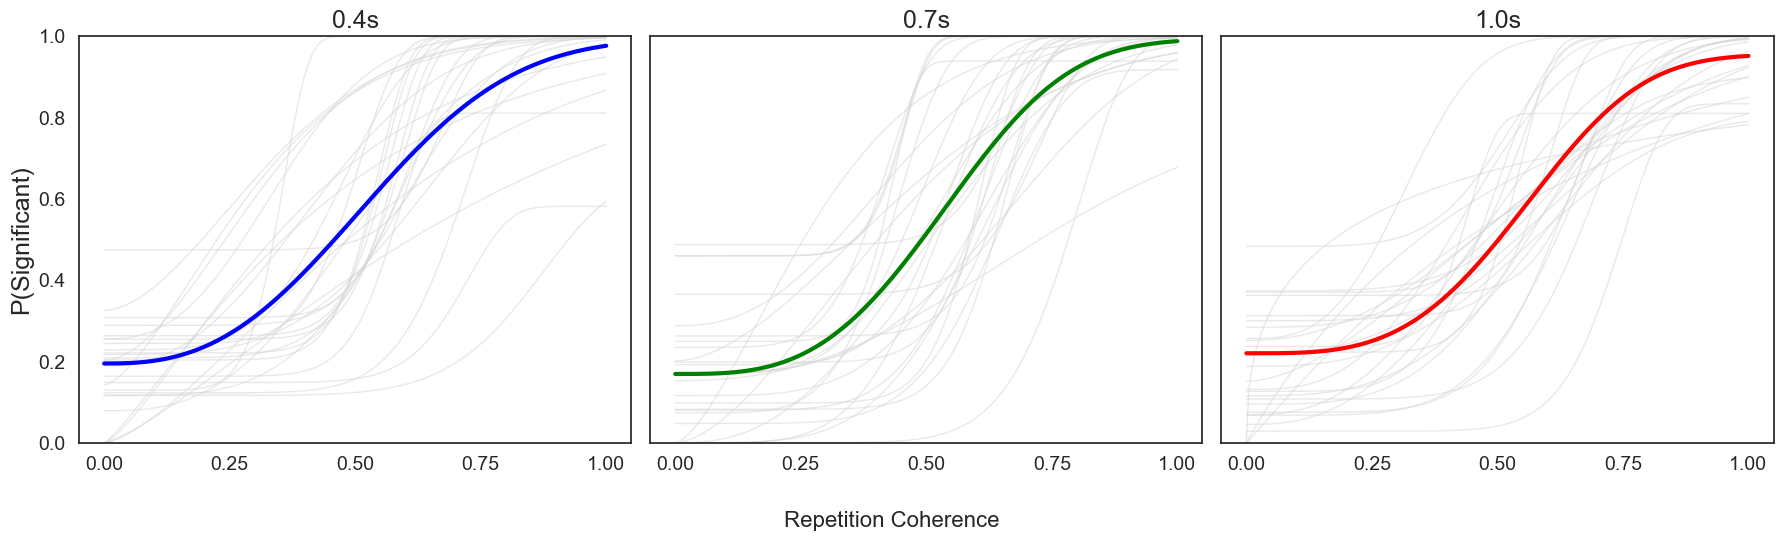

In [38]:
# here threshold correspond to the value passing the 50 percent yes
thresholds_50 = []  # Store (participant_id, unitdur, threshold_percentage)

unit_durations = [0.4, 0.7, 1.0]
colors = ['blue', 'green', 'red']
x_fit = np.linspace(0, 1, 200)
all_fit_results = []

fig, axes = plt.subplots(1, 3, figsize=(18, 5), sharey=True)


# Loop through each subplot axis
for unitdur, color, ax in zip(unit_durations, colors, axes):
    filtered_df = summary_participant[summary_participant['unit_dur'] == unitdur]
    participants = filtered_df['participant_id'].unique()
    fit_results = []

    # Plot individual fits
    for pid in participants:
        pdata = filtered_df[filtered_df['participant_id'] == pid]
        x_data = pdata['percentage'].values
        y_data = pdata['n_sig'].values
        n_trials = pdata['n_trial'].values

        initial_guess = [0.5, 3.0, 0.0, 0.0]
        bounds = [(0.01, 1.0), (0.1, 10.0), (0.0, 0.5), (0.0, 0.5)]

        res = minimize(neg_log_likelihood, initial_guess, args=(x_data, n_trials, y_data),
                       bounds=bounds, method='powell')

        if res.success:
            alpha, beta, gamma, lambd = res.x
            fit_results.append({
                'participant_id': pid,
                'unitdur': unitdur,
                'alpha': alpha,
                'beta': beta,
                'gamma': gamma,
                'lambd': lambd
            })

            y_fit = weibull_psychometric(x_fit, alpha, beta, gamma, lambd)
            ax.plot(x_fit, y_fit, color='lightgray', alpha=0.5, linewidth=1)

            # --- Find threshold where y_fit crosses 0.5 ---
            threshold_index = np.argmax(y_fit > 0.5)
            threshold_percentage = x_fit[threshold_index]

            thresholds_50.append({
            'participant_id': pid,
            'unitdur': unitdur,
            'threshold_percentage': threshold_percentage
            })


            # if any(np.isclose(res.x, [b[0] for b in bounds]) | np.isclose(res.x, [b[1] for b in bounds])):
            #     print(f"Warning: parameter at bounds for unitdur {unitdur}, participant {pid}")


    # Store fits
    fit_df = pd.DataFrame(fit_results)
    all_fit_results.append(fit_df)

    # Group-level fit using summary
    group_data = summary_all[summary_all['unit_dur'] == unitdur]
    x_data_group = group_data['percentage'].values
    y_data_group = group_data['n_sig'].values
    n_trials_group = group_data['n_trial'].values



    res_group = minimize(
        neg_log_likelihood,
        x0=[0.5, 3.0, 0.0, 0.0],
        args=(x_data_group, n_trials_group, y_data_group),
        bounds=[(0.01, 1.0), (0.1, 10.0), (0.0, 1), (0.0, 1)],
        method='powell'
    )


    if res_group.success:
        alpha_group, beta_group, gamma_group, lambd_group = res_group.x
        y_group_fit = weibull_psychometric(x_fit, alpha_group, beta_group, gamma_group, lambd_group)
        ax.plot(x_fit, y_group_fit, color=color, linewidth=3)

    # Styling
    ax.set_title(f'{unitdur}s', fontsize=18)
    #ax.set_xlabel('Repetition Coherence', fontsize=14)
    ax.set_ylim(0, 1)
    ax.set_xticks([0, 0.25, 0.5, 0.75, 1.0])
    ax.tick_params(labelsize= 14)
    ax.grid(False)

fig.text(0.5, -0.07, 'Repetition Coherence', ha='center', fontsize=16)
# Shared y-axis label
axes[0].set_ylabel('P(Significant)', fontsize=18)

# Tight layout and show
plt.tight_layout()
plt.show()

combined_fit_df = pd.concat(all_fit_results, ignore_index=True)


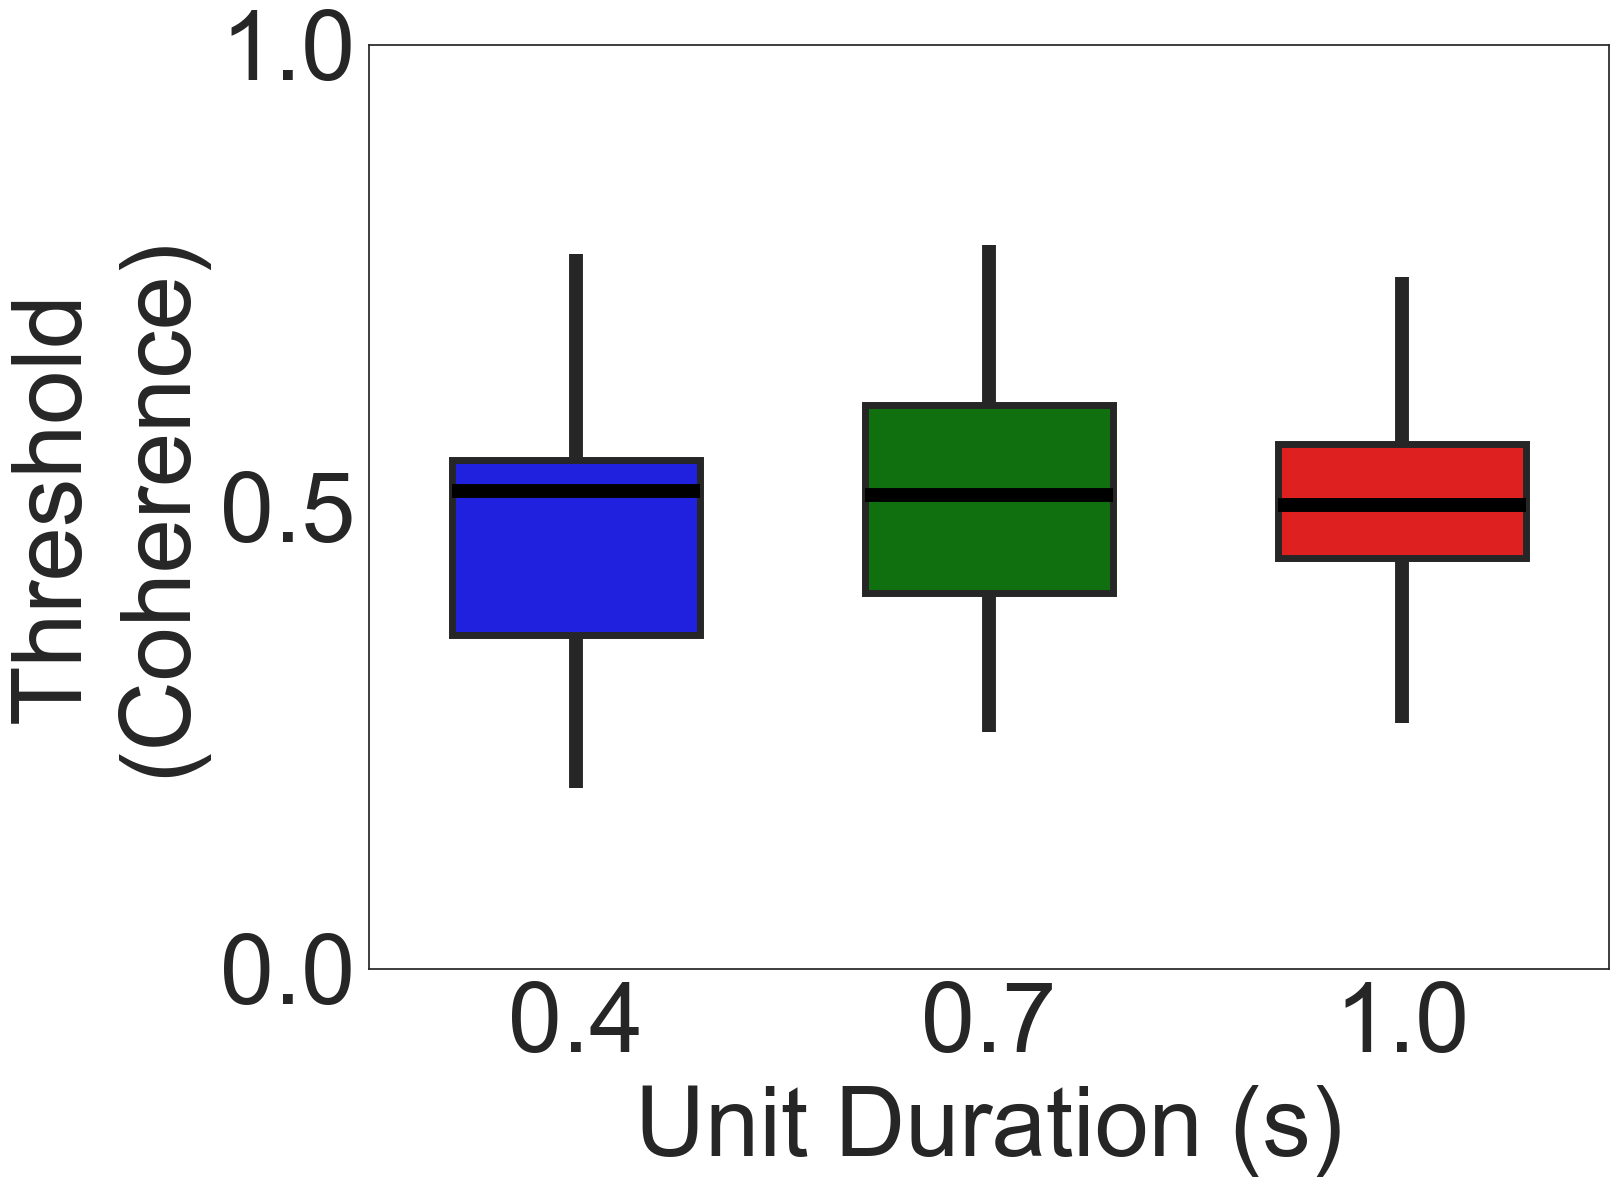

In [42]:
threshold_df = pd.DataFrame(thresholds_50)
threshold_df_tap = threshold_df.dropna(subset = ['threshold_percentage'])
# Convert to string for categorical plotting
threshold_df_tap['unitdur'] = threshold_df_tap['unitdur'].astype(str)

colors = {0.4: 'blue', 0.7: 'green', 1.0: 'red'}
colors_str = {str(k): v for k, v in colors.items()}

# Turn off Seaborn grid styling
sns.set_style("white")  # or "ticks"

# Create figure and axes manually so we can control the grid
fig, ax = plt.subplots(figsize=(16, 12))

# Boxplot
sns.boxplot(
    data=threshold_df_tap,
    x='unitdur',
    y='threshold_percentage',
    palette=colors_str,
    width=0.6,
    ax=ax,
    boxprops=dict(linewidth=5),
    whiskerprops=dict(linewidth=10, solid_capstyle='butt'),  # Thick whiskers
    capprops=dict(visible=False),
    flierprops=dict(marker='', markersize=0),
    medianprops=dict(color='black', linewidth=10)
)

# # Overlay stripplot
# sns.stripplot(
#     data=threshold_df_tap,
#     x='unitdur',
#     y='threshold_percentage',
#     color='black',
#     alpha=0.6,
#     jitter=True,
#     ax=ax
# )

# Labels & Style
ax.set_xlabel('Unit Duration (s)', fontsize=70, labelpad = 10)
ax.set_ylabel('Threshold\n(Coherence)', fontsize=70, labelpad = 10)
# ax.set_title('Distribution of Alpha Parameters', fontsize=20)

ax.grid(False)
plt.xticks(fontsize=70)
plt.yticks([0, 0.5, 1], fontsize=70)
# Axis ticks
# ax.tick_params(axis='both', labelsize=25)
plt.ylim([0,1])
# plt.tight_layout()
plt.show()


In [43]:
# Group by unit duration and compute mean and SEM
threshold_summary = (
    threshold_df.groupby('unitdur')
    .agg(mean_threshold=('threshold_percentage', 'mean'),
         std_threshold=('threshold_percentage', 'std'),
         n=('threshold_percentage', 'count'))
    .reset_index()
)

threshold_summary['sem_threshold'] = threshold_summary['std_threshold'] / threshold_summary['n']**0.5
print(threshold_summary)

   unitdur  mean_threshold  std_threshold   n  sem_threshold
0      0.4        0.487065       0.164246  27       0.031609
1      0.7        0.511818       0.130881  27       0.025188
2      1.0        0.491346       0.124130  27       0.023889


In [44]:
for dur in threshold_df['unitdur'].unique():
    subset = threshold_df[threshold_df['unitdur'] == dur]['threshold_percentage']
    stat, p = stats.shapiro(subset)  # or stats.normaltest(subset) for larger samples
    print(f"Unit duration: {dur}s | p-value: {p:.4f} | {'Normal' if p > 0.05 else 'Not normal'}")

Unit duration: 0.4s | p-value: 0.2034 | Normal
Unit duration: 0.7s | p-value: 0.6418 | Normal
Unit duration: 1.0s | p-value: 0.5813 | Normal


### overall results

In [45]:
percentage_group_data_pid = df_tap_clean.groupby(['percentage', 'participant_id']).agg(
    avg_sig=('significant', 'mean'),
    std=('significant', 'std'),
    n_sig=('significant', 'sum'),
    n_trial=('significant', 'count'),
).reset_index()

In [46]:
percentage_group_data = df_tap_clean.groupby(['percentage']).agg(
    avg_sig=('significant', 'mean'),
    std=('significant', 'std'),
    n_sig=('significant', 'sum'),
    n_trial=('significant', 'count'),
).reset_index()

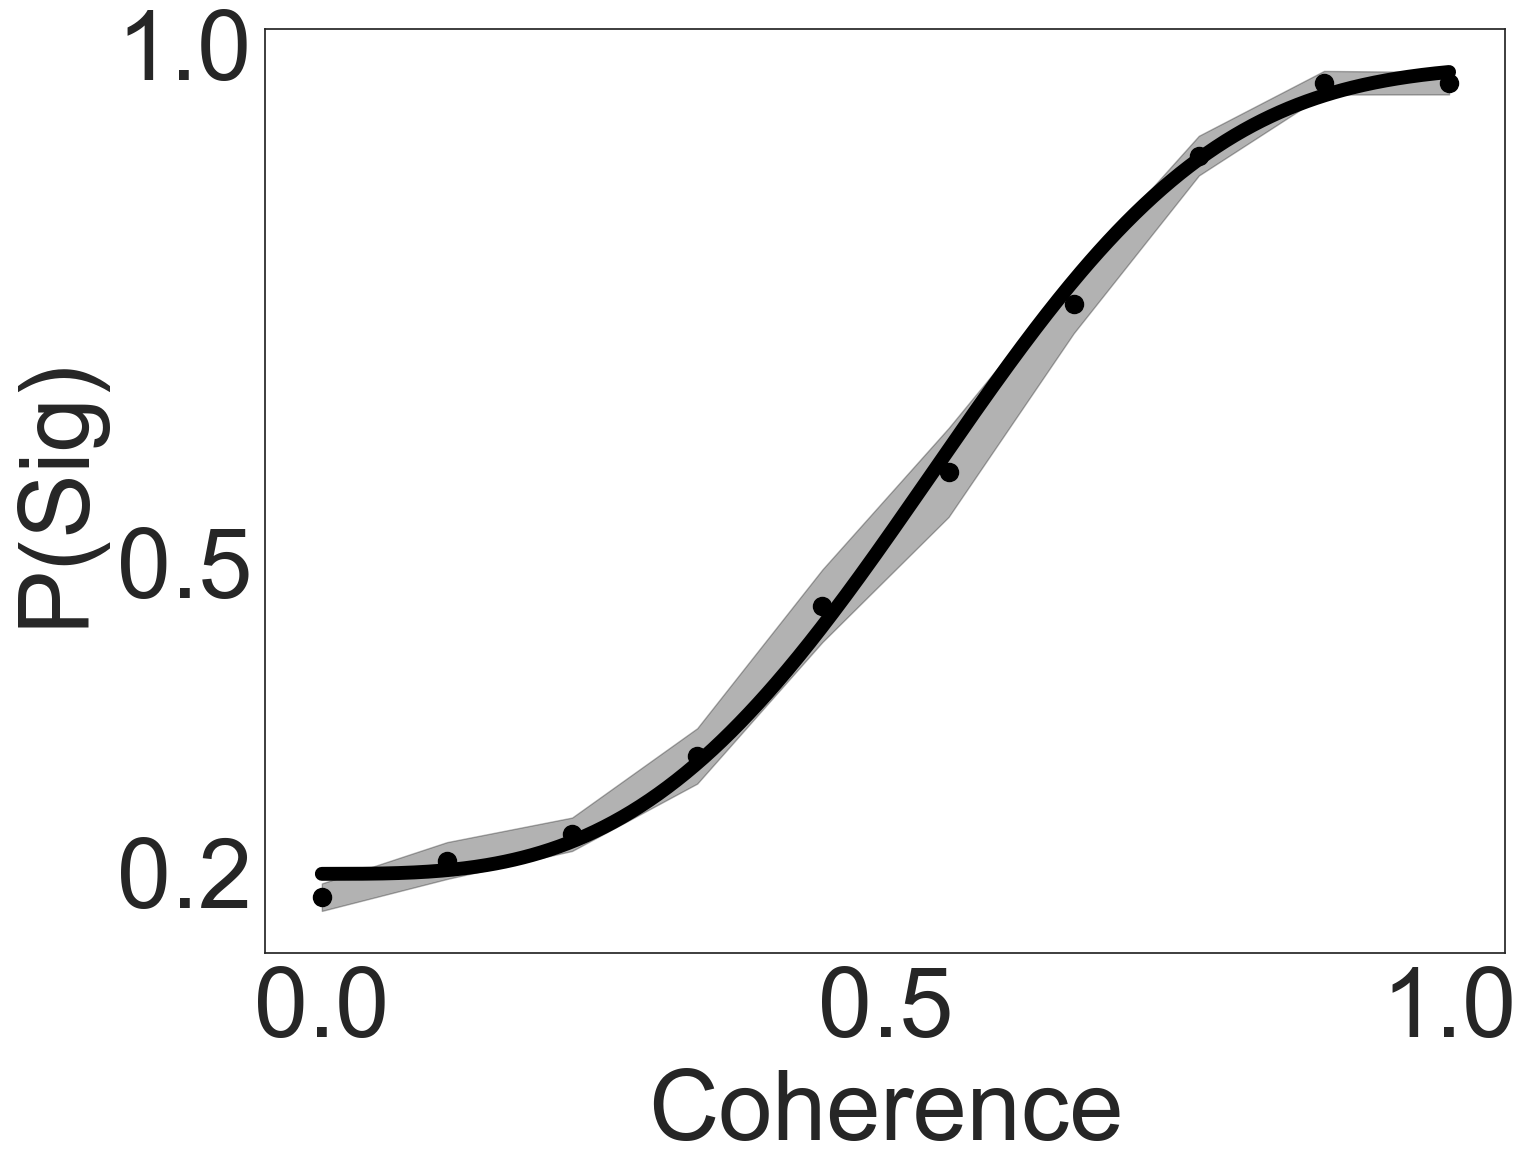

In [48]:
x_fit = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(16, 12))

x_data_group = percentage_group_data['percentage'].values
y_data_group = percentage_group_data['n_sig'].values
n_trials_group = percentage_group_data['n_trial'].values

# # --- Initial parameters and bounds ---
# if unitdur == 0.4:
#     init_params = [0.5, 3.0, 0.2, 0.05]  # last param = sigma
#     bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
# elif unitdur == 0.7:
#     init_params = [0.5, 3.0, 0.1, 0]
#     bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
# elif unitdur == 1.0:
#     init_params = [0.5, 3.0, 0.2, 0.17]
#     bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]


# --- Fit Weibull to individual using MLE ---
init_params = [0.5, 3.0, 0.17, 0]  # alpha, beta, gamma, lambd
bounds = [(0.01, 1), (0.01, 50), (0, 1), (0, 1)]

res = minimize(neg_log_likelihood, init_params,
    args=(x_data_group, n_trials_group, y_data_group),
    bounds=bounds, method='Powell')

if res.success:
    alpha_fit, beta_fit, gamma_fit, lambd_fit = res.x

    fit_results.append({
        'unit_dur': unitdur,
        'alpha': alpha_fit,
        'beta': beta_fit,
        'gamma': gamma_fit,
        'lambda': lambd_fit
    })

    y_fit = weibull_psychometric(x_fit, alpha_fit, beta_fit, gamma_fit, lambd_fit)



ax.plot(x_fit, y_fit, color='black', linewidth=10, label = 'All durations')


# --- Compute actual SEM of participant performance ---
grouped = (
    percentage_group_data_pid
    .groupby(['percentage'])
    .agg(avg_sig=('avg_sig', 'mean'),
            std_sig=('avg_sig', 'std'),
            n_participants=('avg_sig', 'count'))  # participant count
    .reset_index()
)
grouped['sem_sig'] = grouped['std_sig'] / np.sqrt(grouped['n_participants'])

# --- Plot only means as dots ---
ax.plot(grouped['percentage'], grouped['avg_sig'], 'o', color = 'black', markersize=13, label=None)

# --- Shaded SEM area (actual performance variation) ---
ax.fill_between(grouped['percentage'],
                grouped['avg_sig'] - grouped['sem_sig'],
                grouped['avg_sig'] + grouped['sem_sig'], color = 'black', alpha=0.3)

# --- Final plot formatting ---
ax.set_xlabel('Coherence', fontsize=70, labelpad = 10)
ax.set_ylabel('P(Sig)', fontsize=70, labelpad = 10)
# ax.set_xlim(0, 1.02)
# ax.set_ylim(0.1, 1.02)
# ax.legend(title='')
plt.xticks([0, 0.5, 1], fontsize=70)
plt.yticks([0.2, 0.5, 1.0], fontsize=70)
# plt.tight_layout()
plt.show()


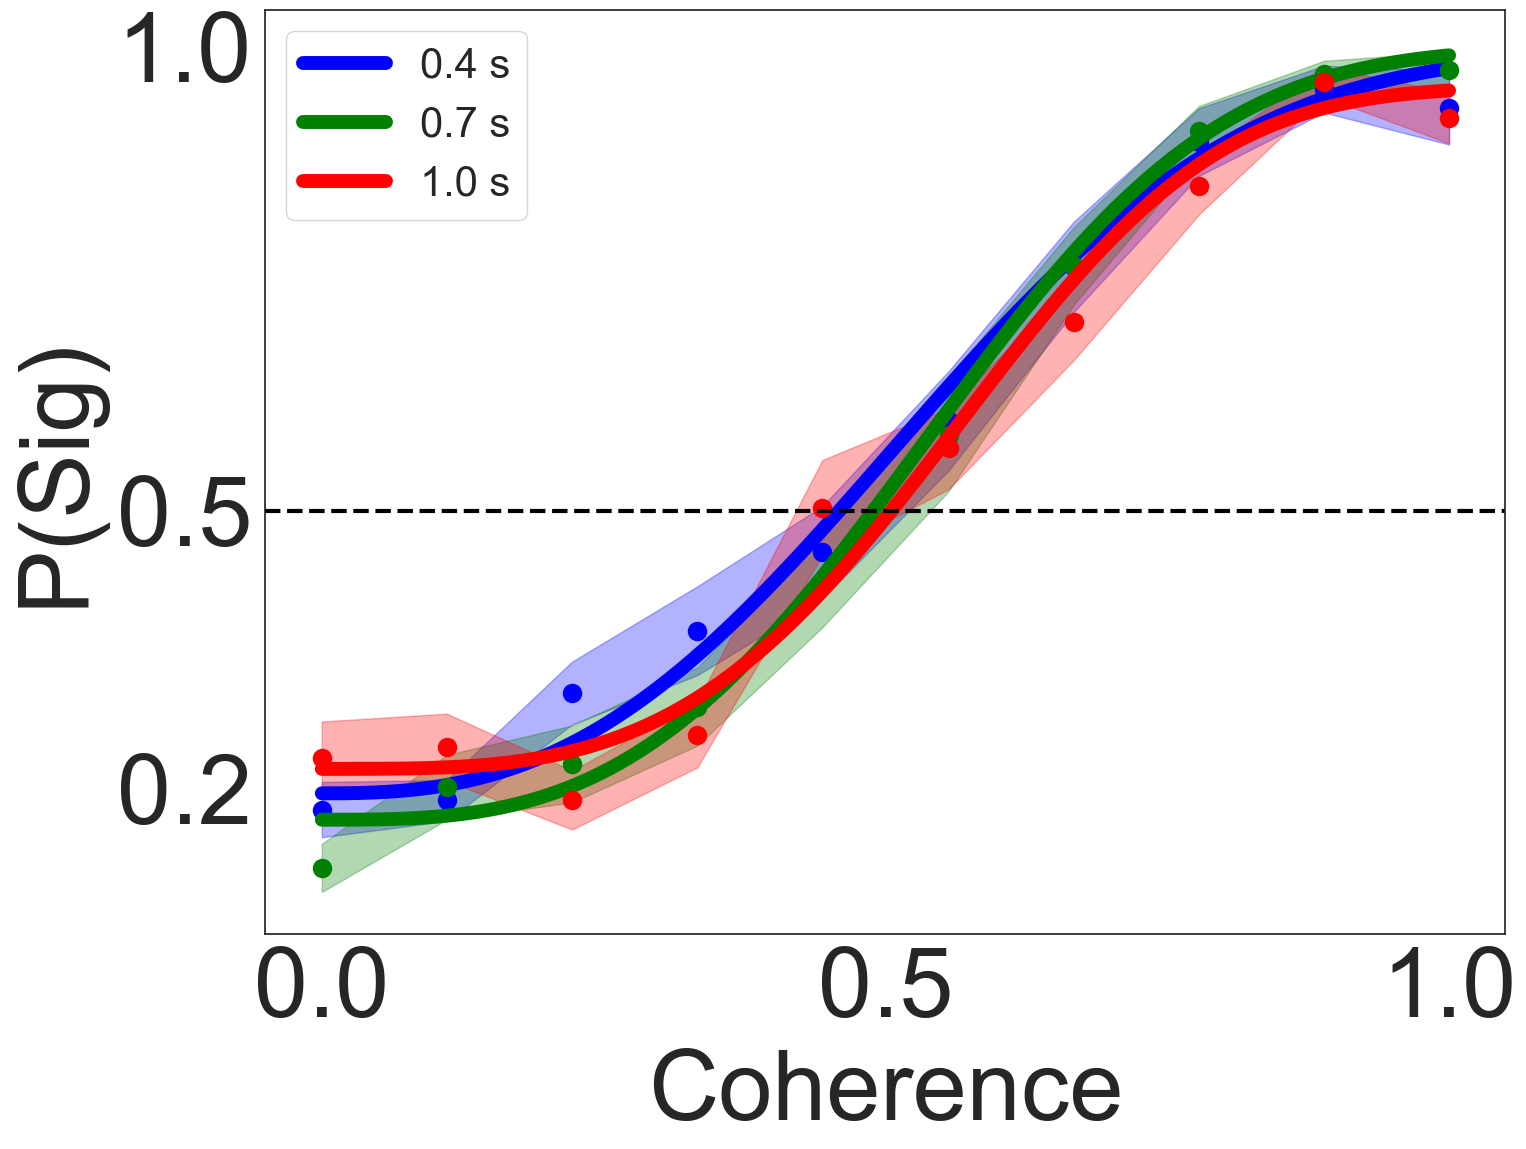

In [49]:
unit_durations = [0.4, 0.7, 1.0]
colors = ['blue', 'green', 'red']
x_fit = np.linspace(0, 1, 500)
fig, ax = plt.subplots(figsize=(16, 12))


all_fit_results = []
for unitdur, color in zip(unit_durations, colors):


    group_data = summary_all[summary_all['unit_dur'] == unitdur]
    x_data_group = group_data['percentage'].values
    y_data_group = group_data['n_sig'].values
    n_trials_group = group_data['n_trial'].values

    # --- Initial parameters and bounds ---
    if unitdur == 0.4:
        init_params = [0.5, 3.0, 0.2, 0.05]  # last param = sigma
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
    elif unitdur == 0.7:
        init_params = [0.5, 3.0, 0.1, 0]
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]
    elif unitdur == 1.0:
        init_params = [0.5, 3.0, 0.2, 0.15]
        bounds = [(0.01, 1), (0.01, 20), (0, 0.5), (0, 0.5)]


    # --- Fit Weibull to individual using MLE ---
    # init_params = [0.5, 3.0, 0, 0]  # alpha, beta, gamma, lambd
    # bounds = [(0.01, 1), (0.01, 50), (0, 1), (0, 1)]

    res = minimize(neg_log_likelihood, init_params,
            args=(x_data_group, n_trials_group, y_data_group),
            bounds=bounds, method='Powell')

    if res.success:
        alpha_fit, beta_fit, gamma_fit, lambd_fit = res.x

        fit_results.append({
            'unit_dur': unitdur,
            'alpha': alpha_fit,
            'beta': beta_fit,
            'gamma': gamma_fit,
            'lambda': lambd_fit
        })

        y_fit = weibull_psychometric(x_fit, alpha_fit, beta_fit, gamma_fit, lambd_fit)

    

    ax.plot(x_fit, y_fit, color=color, linewidth=10, label=f'{unitdur} s')
    

    # --- Compute actual SEM of participant performance ---
    grouped = (
        summary_participant[summary_participant['unit_dur'] == unitdur]
        .groupby(['percentage'])
        .agg(avg_sig=('mean_sig', 'mean'),
             std_sig=('mean_sig', 'std'),
             n_participants=('mean_sig', 'count'))  # participant count
        .reset_index()
    )
    grouped['sem_sig'] = grouped['std_sig'] / np.sqrt(grouped['n_participants'])

    # --- Plot only means as dots ---
    ax.plot(grouped['percentage'], grouped['avg_sig'], 'o',
            color=color, markersize=13, label=None)

    # --- Shaded SEM area (actual performance variation) ---
    ax.fill_between(grouped['percentage'],
                    grouped['avg_sig'] - grouped['sem_sig'],
                    grouped['avg_sig'] + grouped['sem_sig'],
                    color=color, alpha=0.3)

# --- Final plot formatting ---
ax.axhline(y=0.5, color='black', linestyle='--', linewidth=3)
ax.set_xlabel('Coherence', fontsize=70, labelpad = 10)
ax.set_ylabel('P(Sig)', fontsize=70, labelpad = 10)
# ax.set_xlim(0, 1.02)
# ax.set_ylim(0.1, 1.02)
ax.legend(title='', fontsize = 30)
plt.xticks([0, 0.5, 1], fontsize=70)
plt.yticks([0.2, 0.5, 1], fontsize=70)
# plt.tight_layout()
plt.show()


### extract data frames to do analysis on R

In [50]:
prop_sig_df = df_tap_clean.groupby(['unit_dur', 'percentage', 'participant_id']).agg(
    mean_sig=('significant', 'mean'),
    std_sig=('significant', 'std'),
    n_sig = ('significant', 'sum'),
    n_trial = ('significant', 'count'),
).reset_index()


In [ ]:
# prop_sig_df.to_csv('prop_sig_df_for_r.csv', index=False)


In [ ]:
# threshold_df.to_csv('threshold_50_sms_for_r.csv', index = False)

### first significant tap analysis

In [52]:
sig_df = df_tap_clean[df_tap_clean['significant'] == 1]

In [53]:
# all delays
# Prepare the result list for storing delays
tap_onset_delays_list = []
# Iterate over each row in the DataFrame
for index, row in sig_df.iterrows():
    # Select the last 20 presentation cycles (actual_onset_s)
    actual_window = row['actual_onset_s']
    
    # Select tap onsets (tap_onset_s) that fall within the range of the last 20 presentation cycles
    # Define the range as the first and last actual onset in the window
    start_range = actual_window[0]
    # till the end of the trial which includes: time point of presentation, the duration of the presentation, zero pad
    zero_pad = 0.2
    # end_range = actual_window[-1] + row['unit_dur'] + zero_pad
    end_range = actual_window[-1]
    
    # Select tap onsets that are within this range
    tap_window = np.array(row['tap_onset_s'])
    valid_tap_onsets = tap_window[(tap_window >= start_range) & (tap_window <= end_range)]

    # Find the closest indices in actual_window that are less than or equal to the tap onsets using np.searchsorted
    closest_indices = np.searchsorted(actual_window, valid_tap_onsets, side='right') - 1
    
    # Ensure indices are valid (i.e., actual onset is before tap onset)
    valid_indices = (closest_indices >= 0)
    closest_actuals = np.array(actual_window)[closest_indices[valid_indices]]
    valid_tap_onsets = valid_tap_onsets[valid_indices]
    
    # Compute tap onset delays (difference between tap and actual)
    tap_onset_delays = valid_tap_onsets - closest_actuals
    
    # Add the computed delays for this row to the list
    tap_onset_delays_list.append(tap_onset_delays)

# After processing all rows, you can store the delays in the DataFrame or another structure
sig_df['tap_onset_delays_all'] = tap_onset_delays_list

In [54]:
sig_df[['tapping_phases_all', 'tapping_vectors_all']] = sig_df.apply(
    lambda row: pd.Series(get_tapping_vectors(row['tap_onset_delays_all'], row['unit_dur'])), 
    axis=1
)

In [55]:
from scipy.stats import circstd, circmean

In [56]:
def locate_within_range_taps(radians_all, radians_last, consec_len = 5):
    # Mean and standard deviation of the delays (in radians)
    mean_delay = circmean(radians_last)
    std_delay = circstd(radians_last)

    # Compute circular range limits
    lower_bound = (mean_delay - std_delay) % (2 * np.pi)
    upper_bound = (mean_delay + std_delay) % (2 * np.pi)

    # Initialize a list to store indices of values outside the range
    outside_indices = []

    for i, angle in enumerate(radians_all):
        # Normalize angle to [0, 2π]
        norm_angle = angle % (2 * np.pi)
        if not (
            lower_bound <= norm_angle <= upper_bound
            if lower_bound < upper_bound
            else norm_angle >= lower_bound or norm_angle <= upper_bound
        ):
            outside_indices.append(i)

    all_indices = set(range(len(radians_all)))
    inside_indices = sorted(list(all_indices - set(outside_indices)))
    n_outside = len(outside_indices)
    min_inside_index = min(inside_indices) if inside_indices else None

    # --- Find the first inside index followed by `consec_len` consecutive inside values ---
    min_stable_index = None
    for idx in inside_indices:
        # Check if the next (consec_len - 1) indices are also in inside_indices
        window = list(range(idx, idx + consec_len))
        if all(i in inside_indices for i in window):
            min_stable_index = idx
            break

    # Return everything including bounds
    return outside_indices, n_outside, min_inside_index, inside_indices, lower_bound, upper_bound, min_stable_index


In [57]:
# Apply function to each row and extract results into separate columns
results_df = sig_df.apply(
    lambda row: pd.Series(
        locate_within_range_taps(row['tapping_phases_all'], row['tapping_phases_stabil'], consec_len=5)
    ), axis=1
)

results_df.columns = [
    'outside_indices', 'n_outside', 'min_inside_index', 'inside_indices', 'lower_bound', 'upper_bound', 'min_stable_index'
]

# Merge results back into the original dataframe
sig_df = pd.concat([sig_df, results_df], axis=1)

In [58]:
# Ensure fresh phase range calc
sig_df['phase_range'] = (sig_df['upper_bound'] - sig_df['lower_bound']) % (2 * np.pi)

# Filter out missing values
valid_data = sig_df[['participant_id', 'percentage', 'unit_dur', 'min_inside_index', 'phase_range']].dropna()

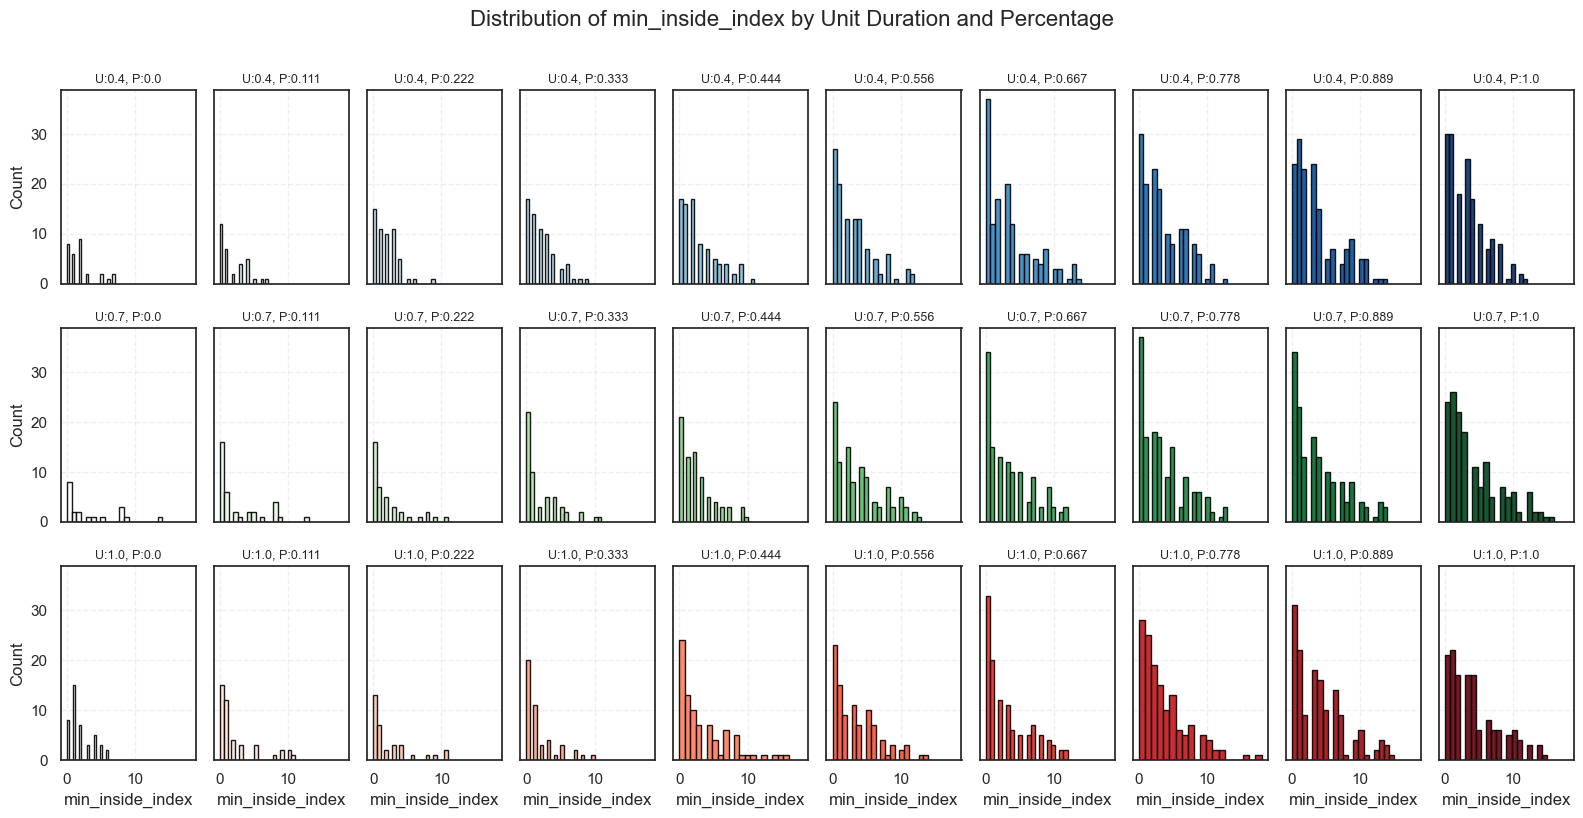

In [59]:
# Define color maps for each unit duration
colormaps = {
    0.4: cm.Blues,
    0.7: cm.Greens,
    1.0: cm.Reds
}

# Create sorted lists of unique levels
unit_durs = sorted(valid_data['unit_dur'].unique())
percentages = sorted(valid_data['percentage'].unique())

# Set up the subplots grid
fig, axes = plt.subplots(len(unit_durs), len(percentages), figsize=(16, 8), sharex=True, sharey=True)
fig.suptitle('Distribution of min_inside_index by Unit Duration and Percentage', fontsize=16, y=1.02)

# Loop through unit durations and percentages
for i, unit in enumerate(unit_durs):
    for j, perc in enumerate(percentages):
        ax = axes[i, j] if len(unit_durs) > 1 else axes[j]  # Handle 1-row case
        subset = valid_data[(valid_data['unit_dur'] == unit) & (valid_data['percentage'] == perc)]

        # Normalize the percentage value within current unit duration for color shading
        unit_data = valid_data[valid_data['unit_dur'] == unit]
        perc_norm = (perc - unit_data['percentage'].min()) / (unit_data['percentage'].max() - unit_data['percentage'].min())
        color = colormaps[unit](perc_norm)

        # Plot histogram
        ax.hist(subset['min_inside_index'], bins=20, color=color, edgecolor='black', alpha=0.9)
        ax.set_title(f'U:{unit}, P:{perc}', fontsize=9)
        ax.grid(True, linestyle='--', alpha=0.3)

        if j == 0:
            ax.set_ylabel('Count')
        if i == len(unit_durs) - 1:
            ax.set_xlabel('min_inside_index')

plt.tight_layout()
plt.subplots_adjust(top=0.92)
plt.show()


In [60]:
grouped_participant = valid_data.groupby(['percentage', 'unit_dur', 'participant_id']).agg({
    'min_inside_index': 'median',
    'phase_range': 'mean'
}).reset_index()

In [61]:
filtered_tap_data = grouped_participant[grouped_participant['percentage'] == 1]

In [62]:
filtered_tap_data['min_inside_index'] = filtered_tap_data['min_inside_index'] + 1

In [64]:
from scipy.stats import sem

# Now group across participants
summary_across_participants = grouped_participant.groupby(['percentage', 'unit_dur']).agg(
    min_inside_index_mean=('min_inside_index', 'mean'),
    min_inside_index_median=('min_inside_index', 'median'),
    min_inside_index_std=('min_inside_index', 'std'),
    min_inside_index_sem=('min_inside_index', sem),
    
    phase_range_mean=('phase_range', 'mean'),
    phase_range_median=('phase_range', 'median'),
    phase_range_std=('phase_range', 'std'),
    phase_range_sem=('phase_range', sem)
).reset_index()

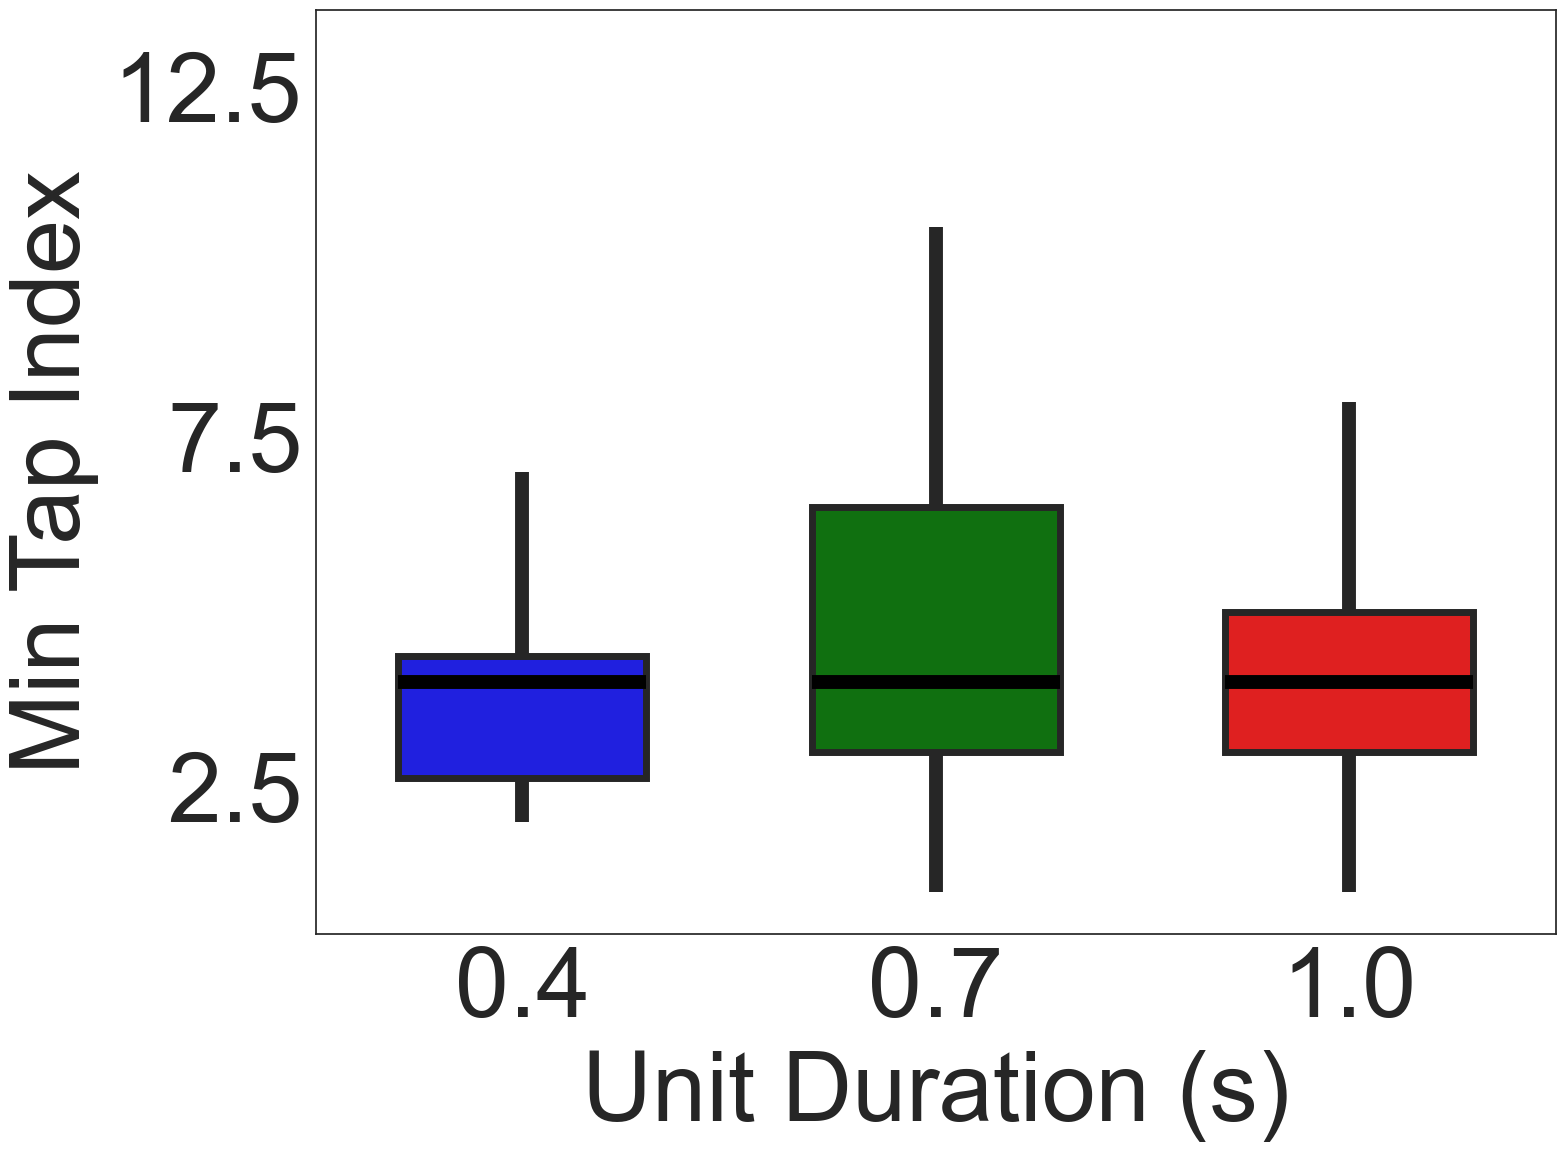

In [65]:
# Turn off Seaborn grid styling
sns.set_style("white")  # or "ticks"

# Create figure and axes manually so we can control the grid
fig, ax = plt.subplots(figsize=(16, 12))

# Boxplot
sns.boxplot(
    data= filtered_tap_data,
    x='unit_dur',
    y='min_inside_index',
    palette=colors_str,
    width=0.6,
    ax=ax,
    boxprops=dict(linewidth=5),
    whiskerprops=dict(linewidth=10, solid_capstyle='butt'),  # Thick whiskers
    capprops=dict(visible=False),
    flierprops=dict(marker='', markersize=0),
    medianprops=dict(color='black', linewidth=10)
)

# # Overlay stripplot
# sns.stripplot(
#     data=threshold_df_tap,
#     x='unitdur',
#     y='threshold_percentage',
#     color='black',
#     alpha=0.6,
#     jitter=True,
#     ax=ax
# )

# Labels & Style

# ax.set_title('Distribution of Alpha Parameters', fontsize=20)

ax.grid(False)
ax.set_xlabel('Unit Duration (s)', fontsize=70, labelpad=10)
ax.set_ylabel('Min Tap Index', fontsize=70, labelpad=10)
plt.xticks(fontsize=70)
plt.yticks([2.5, 7.5, 12.5], fontsize=70)
# Axis ticks
# ax.tick_params(axis='both', labelsize=25)
# plt.ylim([0,1])
# plt.tight_layout()
plt.show()


In [83]:
filtered_sig_df = sig_df[sig_df['percentage'] == 1.0]

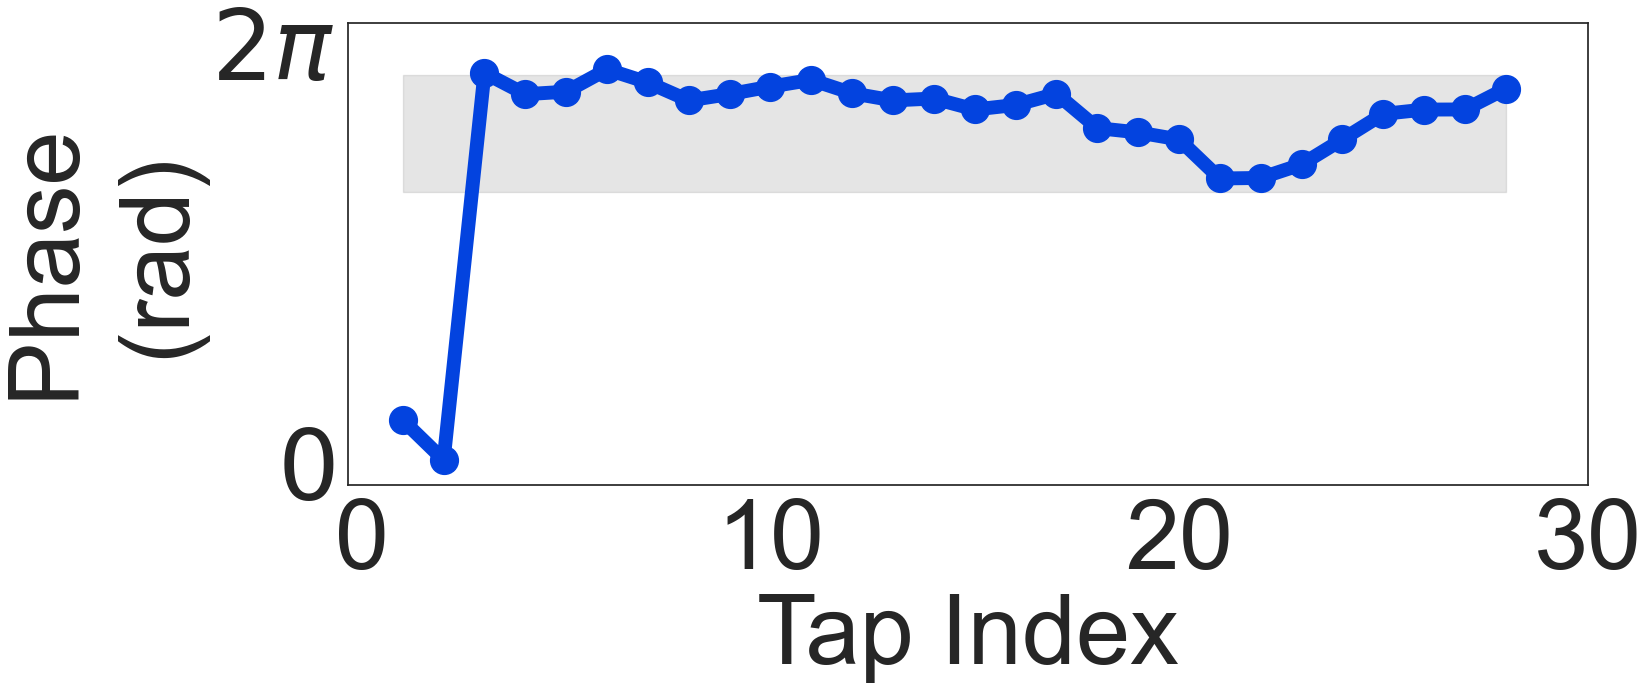

In [85]:
# Pick a few trials to visualize (e.g., first 2 rows)
example_trials = filtered_sig_df.iloc[33:34]

for idx, row in example_trials.iterrows():
    tap_delays = row['tap_onset_delays_all']   
    n_taps = len(tap_delays)
    tap_indices = np.arange(1, n_taps + 1)

    # Convert tap delays (sec) → radians in 0–2π
    tap_delays_rad = (tap_delays / row['unit_dur']) * 2*np.pi
    
    # Convert phase range to radians
    phase_range_rad = row['phase_range']

    fig, ax = plt.subplots(figsize=(16, 6))

    ax.plot(tap_indices, tap_delays_rad, 'o-', color='#0343DF', linewidth=10, markersize=20)

    # Shade mean ± phase range
    mean_delay_rad = np.mean(tap_delays_rad)
    ax.fill_between(
        tap_indices,
        mean_delay_rad - phase_range_rad,
        mean_delay_rad + phase_range_rad,
        color='gray', alpha=0.2
    )

    ax.set_xlabel("Tap Index", fontsize=70)
    ax.set_ylabel("Phase \n(rad)", fontsize=70)
    ax.set_ylim(0, 2*np.pi)

    y_min = 0 - 0.1*np.pi
    y_max = 2*np.pi + 0.1*np.pi
    ax.set_ylim(y_min, y_max)

    # Set y-ticks at 0, π/2, π, 3π/2, 2π
    y_ticks = [0, 2*np.pi]
    y_labels = [r"$0$",  r"$2\pi$"]
    ax.set_yticks(y_ticks)
    ax.set_yticklabels(y_labels, fontsize=70)
    x_ticks = [0, 10, 20, 30]
    ax.set_xticks(x_ticks)

    ax.tick_params(labelsize=70)
    plt.show()
